
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

In [6]:
import numpy as np

np.random.seed(42)

X = np.random.uniform(0, 1, (1000,2))

epsilon = np.random.normal(0, 1, 1000)

x1 = X[:,0]
x2 = X[:,1]

y = 3*x1 + 5*x2 + 3 + epsilon

ones = np.ones(1000)

X = np.c_[ones, X]

X[:5]

array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)

&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.

<details>

<summary>Answer</summary>

a) 

<img src="../data/grad_desc_converg.png" height="200"/>

b) 

<img src="../data/grad_desc_converg_001.png" height="200"/>

</details>

---

Theta A:  [3.21446629 2.88863975 4.7214914 ]
Theta B:  [3.21399188 2.88900455 4.72202193]


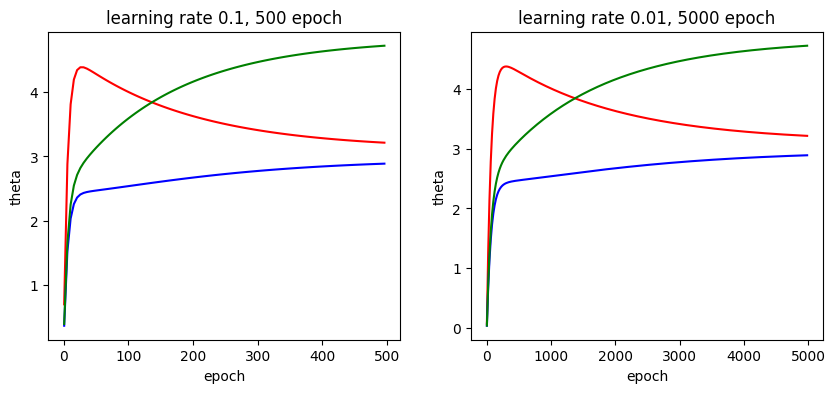

In [36]:
import matplotlib.pyplot as plt

thetaA = np.zeros(3)
thetaB = np.zeros(3)

etaA = 0.1
etaB = 0.01

theta_listA = []
epochsA = []

theta_listB = []
epochsB = []

for epoch in range(1, 501):

    y_pred = X @ thetaA

    gradient = X.T @ (y_pred - y)/(len(y_pred))

    thetaA = thetaA - etaA * gradient

    if epoch % 5 == 1:
        theta_listA.append(thetaA.copy())
        epochsA.append(epoch)

for epoch in range(1, 5001):

    y_pred = X @ thetaB

    gradient = X.T @ (y_pred - y)/(len(y_pred))

    thetaB = thetaB - etaB * gradient

    if epoch % 20 == 1:
        theta_listB.append(thetaB.copy())
        epochsB.append(epoch)

theta_arrA = np.array(theta_listA)
theta_arrB = np.array(theta_listB)

fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=100)
ax[0].plot(epochsA, theta_arrA[:,0], c="red")
ax[0].plot(epochsA, theta_arrA[:,1], c="blue")
ax[0].plot(epochsA, theta_arrA[:,2], c="green")
ax[0].set_title("learning rate 0.1, 500 epoch")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("theta")

ax[1].plot(epochsB, theta_arrB[:,0], c="red")
ax[1].plot(epochsB, theta_arrB[:,1], c="blue")
ax[1].plot(epochsB, theta_arrB[:,2], c="green")
ax[1].set_title("learning rate 0.01, 5000 epoch")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("theta")

print("Theta A: ", theta_listA[-1])
print("Theta B: ", theta_listB[-1])

## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

Theta C:  [3.11819188 2.94983031 4.84348367]
Theta D:  [3.0327501  2.8893659  4.72824679]


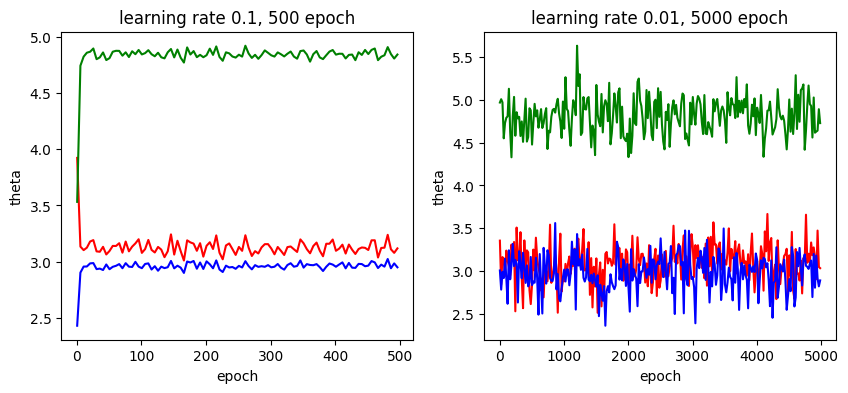

In [55]:
thetaC = np.zeros(3)

theta_listC = []
epochsC =[]
etaC = 0.01

thetaD = np.zeros(3)

theta_listD = []
epochsD =[]
etaD = 0.1

for epoch in range(1, 501):
    indices = np.random.permutation(len(X))
    for i in indices:
        pred = X[i].T @ thetaC

        gradient = (pred - y[i]) * X[i]

        thetaC = thetaC - etaC * gradient

    if epoch % 5 == 1:
        theta_listC.append(thetaC.copy())
        epochsC.append(epoch)

for epoch in range(1, 5001):
    indices = np.random.permutation(len(X))
    for i in indices:
        pred = X[i].T @ thetaD

        gradient = (pred - y[i]) * X[i]

        thetaD = thetaD - etaD * gradient

    if epoch % 20 == 1:
        theta_listD.append(thetaD.copy())
        epochsD.append(epoch)

theta_arrC = np.array(theta_listC)
theta_arrD = np.array(theta_listD)

fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=100)
ax[0].plot(epochsC, theta_arrC[:,0], c="red")
ax[0].plot(epochsC, theta_arrC[:,1], c="blue")
ax[0].plot(epochsC, theta_arrC[:,2], c="green")
ax[0].set_title("learning rate 0.1, 500 epoch")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("theta")

ax[1].plot(epochsD, theta_arrD[:,0], c="red")
ax[1].plot(epochsD, theta_arrD[:,1], c="blue")
ax[1].plot(epochsD, theta_arrD[:,2], c="green")
ax[1].set_title("learning rate 0.01, 5000 epoch")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("theta")

print("Theta C: ", theta_listC[-1])
print("Theta D: ", theta_listD[-1])

## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---